In [1]:
import tinydb
import sys
import os
import rich
import onnx


%load_ext autoreload
%autoreload 2

path = os.path.abspath(".")

print(f"Project: {path}")
from batching_security_checker.report.stages import Report, get_report_converter
from batching_security_checker.report import stages

from batching_security_checker.core import model_summary


Project: /home/kuenico/dev/batching-security-checker


/home/kuenico/dev/batching-security-checker/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
no_license_repos = [
    "onnx-community/deepseek-coder-1.3b-instruct-ONNX",
    "onnx-community/DeepSeek-R1-Distill-Llama-8B-ONNX-DirectML-GenAI-INT4",
    "onnx-community/Meta-Llama-3.1-8B-Instruct-ONNX-DirectML-GenAI-INT4",
    "onnx-community/ultravox-v0_5-llama-3_2-1b-ONNX",
    "onnx-community/ISNet-ONNX",
    "onnx-community/Llama-Guard-3-1B",
    "onnx-community/Llama-3.2-3B",
    "onnx-community/Llama-3.2-3B-Instruct",
    "onnx-community/Llama-3.2-1B",
    "onnx-community/Llama-3.2-1B-Instruct",
    "onnx-community/DeepSeek-R1-Distill-Qwen-1.5B-ONNX",
    "onnx-community/Llama-3.2-3B-instruct-hexagon-npu-assets",
    "onnx-community/TinyLlama-1.1B-Chat-v1.0-ONNX",
    "onnx-community/Llama-3.2-1B-Instruct-onnx-web-gqa",
    "onnx-community/Llama-3.2-3B-Instruct-onnx-web-gqa",
    "onnx-community/tiny-random-LlamaForCausalLM-ONNX",
    "onnx-community/Llama-3.2-1B-Instruct-ONNX",
    "onnx-community/Llama-3.2-3B-Instruct-ONNX",
    "onnx-community/Llama-3.2-3B-Instruct-onnx-web",
    "onnx-community/Llama-3.2-1B-Instruct-q4f16",
    "onnx-community/yolov10s",
    "onnx-community/yolov10n",
    "onnx-community/yolov10x",
    "onnx-community/yolov10b",
    "onnx-community/yolov10l",
    "onnx-community/yolov10m",
    "onnx-community/YOLOv10"
]

In [3]:
database_path = "./results/report_db.json"

db = tinydb.TinyDB(database_path)
report_db = db.table("report")
dimparam_db = db.table("dimparam")
exception_db = db.table("exception")

converter = get_report_converter()
reports = []
license_skip = 0
for r in report_db.all():

    report: Report = converter.structure(r, Report)

    if any(report.model_id.startswith(x) for x in no_license_repos):
        print(f"Skipping model {report.model_id} due to license")
        license_skip += 1
    else:
        reports.append((r.doc_id, report))

rich.print(reports[0])

rich.print(f"Skipped due to license: {license_skip}")

Skipping model onnx-community/Llama-3.2-3B-instruct-hexagon-npu-assets/dequantizer.onnx due to license
Skipping model onnx-community/Llama-3.2-3B-instruct-hexagon-npu-assets/quantizer.onnx due to license
Skipping model onnx-community/Llama-3.2-3B-instruct-hexagon-npu-assets/position-shifter.onnx due to license
Skipping model onnx-community/yolov10n/onnx/model_int8.onnx due to license
Skipping model onnx-community/Llama-3.2-3B-instruct-hexagon-npu-assets/position-processor.onnx due to license
Skipping model onnx-community/yolov10n/onnx/model_fp16.onnx due to license
Skipping model onnx-community/yolov10s/onnx/model_int8.onnx due to license
Skipping model onnx-community/YOLOv10/yolov10n.onnx due to license
Skipping model onnx-community/yolov10s/onnx/model_fp16.onnx due to license
Skipping model onnx-community/yolov10m/onnx/model_int8.onnx due to license
Skipping model onnx-community/yolov10b/onnx/model_int8.onnx due to license
Skipping model onnx-community/tiny-random-LlamaForCausalLM-ON

(
    1,
    Report(
        model_id='onnx-community/Phi-3-mini-instruct-hexagon-npu-assets/dequantizer.onnx',
        stages=StageInfo(
            selection=SelectionStage(
                status='included',
                metadata={
                    'repo_id': 'onnx-community/Phi-3-mini-instruct-hexagon-npu-assets',
                    'files': [{'file': 'dequantizer.onnx', 'bytes': 181, 'size_str': '181 Bytes'}],
                    'name': 'dequantizer'
                },
                desc=None
            ),
            download=DownloadStage(
                status='success',
                local_path='/home/ubuntu/batching-security-checker/data/hf-onnx-community/onnx-community/Phi-3-mini
-instruct-hexagon-npu-assets/dequantizer.onnx'
            ),
            load=LoadStage(
                status='success',
                operator_histogram={'': {'Cast': 1}},
                dim_params=['seq_len'],
                inputs={'tensor_0': (1, 'seq_len', 32064)},
                outputs={'tensor_1': (1, 'seq_len', 32064)},
                opset=[
                    {'domain': '', 'version': 17},
                    {'domain': 'experimental', 'version': 1},
                    {'domain': 'com.microsoft', 'version': 1}
                ],
                errors=None
            ),
            shape_inference=ShapeInferenceStage(
                status='fixed',
                dim_param_values={'seq_len': 12},
                dynamic_output_nodes=None,
                errors=None
            ),
            batch_dim=BatchDimStage(
                status='nobatch',
                batch_dim_params=None,
                inputs_public=None,
                outputs_public=None,
                inputs_batch_dim=None,
                outputs_batch_dim=None,
                inputs_missing_batch_dim=None,
                outputs_missing_batch_dim=None
            ),
            operator=None,
            interference_check=None
        ),
        model=Model(
            name='onnx-community/Phi-3-mini-instruct-hexagon-npu-assets/dequantizer.onnx',
            src=LocalSrc(
                path='/home/ubuntu/batching-security-checker/data/hf-onnx-community/onnx-community/Phi-3-mini-instr
uct-hexagon-npu-assets/dequantizer.onnx',
                type='local'
            ),
            labeler=None,
            dim_params=None,
            model_fixer=ModelFixer(),
            _onnx_model=None
        )
    )
)

Skipped due to license: 162

In [5]:
def find_errors(reports, stage_name: str, status: list[str]):

    stats = stages.Stats()
    stage_indices = {s.stage_name: i for i, s in enumerate(stats.get_stages())}

    idx = stage_indices[stage_name]

    stages_matching = []

    for doc_id, r in reports:
        r: Report = r

        stage = r.stages.get_stages()[idx]
        if stage is not None and stage.status in status:
            stages_matching.append((r, stage))

    return stages_matching



def _group_errors(stages_matching, errors, show_first_n=0, show_opintersection=False):

    rich.print("=========Unassigned Errors=========")

    errors_opset = {e: set() for e in errors.keys()}

    for report, stage in stages_matching:
        is_assigned = False
        for search, lst in errors.items():
            if any(search in e for e in stage.errors):
                lst.append(report.model_id)
                is_assigned = True
                if show_opintersection:
                    opset = set()
                    for domain, ops in report.stages.load.operator_histogram.items():
                        for op in ops.keys():
                            opset.add((domain, op))
                    if errors_opset[search]:
                        errors_opset[search] = opset.intersection(errors_opset[search])
                    else:
                        errors_opset[search] = opset
        if not is_assigned:
            rich.print(f"\n\n\n{report.model_id}")
            rich.print(stage.errors)



    rich.print("=========Assigned Errors (+ Frequency) =========")

    for e, lst in errors.items():
        print(f"{e}:  {len(lst)}")
        for i in range(min(len(lst), show_first_n)):
            print(f"   {lst[i]}")

        if show_opintersection:
            tmp = {', '.join(map(lambda x: f"{x[0]}.{x[1]}", errors_opset.get(e)))}
            print(f"Intersection of operators: {tmp}")

    rich.print("=================================")


def load_errors(reports):
    stages_matching = find_errors(reports, 'Load Stage', 'failed')


    errors = {
        "No Op registered for LayerNormalization with domain_version of 14": [],
        #"No Op registered for SimplifiedLayerNormalization with domain_version of 14": [],
        #"No Op registered for SimplifiedLayerNormalization with domain_version of 21": [],
        ", but it doesn't exist or is not accessible.": [],
        "Nodes in a graph must be topologically sorted, however input": [],
        "OpType: If": [],
        "is not an output of any node in graph.": [],
    }

    _group_errors(stages_matching, errors, 3)




def shape_inference_errors(reports):
    stages_matching = find_errors(reports, 'Shape Inference Stage', 'failed')

    errors = {
        "Nodes in a graph must be topologically sorted, however input": [],
        "buffer size must be a multiple of element size": [],
        "Contradicts existing dimension value": [],
        "cannot reshape array of size": []
    }

    _group_errors(stages_matching, errors, 3)


def interference_check_errors(reports):
    stages_matching = find_errors(reports, 'Interference Check Stage', 'failed')

    errors = {
        "skipping model: ": [],
        #"combined_args must be even length: len=9  (op=None)": [],
        #"can only concatenate tuple (not \"list\") to tuple": [],
        #"onnx_taint_clip() got an unexpected keyword argument 'amax'": [],
        #"only version with two args is currently supported: len(input_args)=5": [],
        "output.dtype=dtype('float32') != expected_data_dtype=dtype('float16')": [],
        #"Erf version 9 is not implemented. Only have those versions: ['version_13'].": [],
        "Unknown dim type: dim=dim_value: 0": [],
        "The problematic value is of type <class 'str'> and was passed to the function at path combined_inputs[6]": [],
        "min got incompatible shapes for broadcasting: (4, 24, 12, 12), (4, 4, 12, 12).": [],
        "a and b must have the same shape[:-2]": [],
        #"not found in graph: you may need to run shape inference on the model first": [],

    #    "Nodes in a graph must be topologically sorted, however input": [],
    #    "buffer size must be a multiple of element size": [],
    #    "Contradicts existing dimension value": [],
    #    "cannot reshape array of size": []
    }

    _group_errors(stages_matching, errors, 3, show_opintersection=True)

def interference_check_interference(reports):
    stages_matching = find_errors(reports, 'Interference Check Stage', 'interference')


    reasons = {
        "DynamicQuantizeLinear": lambda report: "DynamicQuantizeLinear" in report.stages.load.operator_histogram.get("ai.onnx", {})
    }

    reasons_count = {name: 0 for name in reasons.keys()}

    no_reason = 0

    for report, stage in stages_matching:
        has_reason = False
        for name, func in reasons.items():
            if func(report):
                has_reason = True
                reasons_count[name] += 1

        if not has_reason:
            no_reason+=1
            #rich.print(stage)

    rich.print(reasons_count)

    rich.print(f"NO REASON: {no_reason}")






rich.print("[bold]LOAD STAGE ERRORS:[/bold]")
load_errors(reports)

rich.print("[bold]SHAPE INFERENCE STAGE ERRORS:[/bold]")
shape_inference_errors(reports)

rich.print("[bold]INTERFERENCE CHECK STAGE ERRORS:[/bold]")
interference_check_errors(reports)

rich.print("[bold]REASONS FOR INTERFERENCE:[/bold]")
interference_check_interference(reports)


LOAD STAGE ERRORS:

=========Unassigned Errors=========

=========Assigned Errors (+ Frequency) =========

No Op registered for LayerNormalization with domain_version of 14:  4
   onnx-community/Phi-3-vision-128k-instruct/onnx/vision_encoder_q4.onnx
   onnx-community/Phi-3.5-vision-instruct/onnx/vision_encoder_q4.onnx
   onnx-community/moondream2.text_model-ONNX/onnx/model_int8.onnx
, but it doesn't exist or is not accessible.:  1
   onnx-community/stable-diffusion-v1-5-ONNX/unet/model.onnx
Nodes in a graph must be topologically sorted, however input:  20
   onnx-community/silero-vad/onnx/model_fp16.onnx
   onnx-community/whisper-tiny.en/onnx/decoder_model_merged_fp16.onnx
   onnx-community/whisper-tiny/onnx/decoder_model_merged_fp16.onnx
OpType: If:  31
   onnx-community/silero-vad/onnx/model_int8.onnx
   onnx-community/silero-vad/onnx/model_fp16.onnx
   onnx-community/tiny-random-MarianMTModel/onnx/decoder_model_merged_fp16.onnx
is not an output of any node in graph.:  16
   onnx-community/tiny-random-MarianMTModel/onnx/decoder_model_merged_fp16.onnx
   onnx-community/moonshine-tiny-ONNX/

=================================

...

skipping model: :  10
   onnx-community/lite-whisper-large-v3-ONNX/onnx/encoder_model_int8.onnx
   onnx-community/lite-whisper-large-v3-turbo-acc-ONNX/onnx/encoder_model_int8.onnx
   onnx-community/lite-whisper-large-v3-acc-ONNX/onnx/encoder_model_int8.onnx
Intersection of operators: {'ai.onnx.Transpose, ai.onnx.Reshape, ai.onnx.Mul, ai.onnx.Cast, ai.onnx.Sub, ai.onnx.MatMulInteger, ai.onnx.Erf, ai.onnx.DynamicQuantizeLinear, ai.onnx.Add, ai.onnx.Softmax, ai.onnx.Sqrt, ai.onnx.ReduceMean, ai.onnx.ConvInteger, ai.onnx.MatMul, ai.onnx.Pow, ai.onnx.Div'}
output.dtype=dtype('float32') != expected_data_dtype=dtype('float16'):  6
   onnx-community/kb-whisper-tiny-ONNX/onnx/decoder_with_past_model_fp16.onnx
   onnx-community/kb-whisper-tiny-ONNX/onnx/decoder_model_fp16.onnx
   onnx-community/kb-whisper-base-ONNX/onnx/decoder_with_past_model_fp16.onnx
Intersection of operators: {'ai.onnx.Range, ai.onnx.Expand, ai.onnx.ReduceMean, ai.onnx.Where, ai.onnx.Transpose, ai.onnx.Reshape, ai.onnx.Great

=================================

REASONS FOR INTERFERENCE:

{'DynamicQuantizeLinear': 269}

NO REASON: 0

## Batching Assignment


- There are models that do not have a simple batching dimension as an output, but instead a range of the batching dimension is the result of a single sample in the batch. This could be analysed by our IFC but requires custom label assignment of the output:

Model onnx-community/siglip2-large-patch16-512-ONNX/onnx/vision_model_int8.onnx
Doc ID: 1186
Inputs: {'tensor_0': ('batch_size', 'num_channels', 'height', 'width')}
Outputs: {'tensor_2726': ('floor(batch_size*floor(height/16)*floor(width/16)/1024)', 1024, 1024), 'tensor_2847': ('floor(batch_size*floor(height/16)*floor(width/16)/1024)', 1024)}


Model onnx-community/PE-Core-B16-224-ONNX/onnx/text_model_int8.onnx
Doc ID: 1217
Inputs: {'tensor_1': ('batch_size', 32)}
Outputs: {'tensor_2575': ('floor(Flatten_1453_o0__d1*batch_size/1024)', 1024)}


Model onnx-community/PE-Core-L14-336-ONNX/onnx/text_model_int8.onnx
Doc ID: 1218
Inputs: {'tensor_1': ('batch_size', 32)}
Outputs: {'tensor_2575': ('floor(Flatten_1453_o0__d1*batch_size/1024)', 1024)}


Model onnx-community/siglip2-base-patch16-224-ONNX/onnx/model_int8.onnx
Doc ID: 1229
Inputs: {'tensor_15': ('text_batch_size', 'sequence_length'), 'tensor_0': ('image_batch_size', 'num_channels', 'height', 'width')}
Outputs: {'tensor_2989': ('floor(image_batch_size*floor(height/16)*floor(width/16)/196)', 'text_batch_size'), 'tensor_2988': ('text_batch_size', 'floor(image_batch_size*floor(height/16)*floor(width/16)/196)'), 'tensor_2955': ('text_batch_size', 768), 'tensor_2982': 
('floor(image_batch_size*floor(height/16)*floor(width/16)/196)', 768)}


Model onnx-community/siglip2-base-patch16-256-ONNX/onnx/model_int8.onnx
Doc ID: 1230
Inputs: {'tensor_15': ('text_batch_size', 'sequence_length'), 'tensor_0': ('image_batch_size', 'num_channels', 'height', 'width')}
Outputs: {'tensor_2989': ('floor(image_batch_size*floor(height/16)*floor(width/16)/256)', 'text_batch_size'), 'tensor_2988': ('text_batch_size', 'floor(image_batch_size*floor(height/16)*floor(width/16)/256)'), 'tensor_2955': ('text_batch_size', 768), 'tensor_2982': 
('floor(image_batch_size*floor(height/16)*floor(width/16)/256)', 768)}


Model onnx-community/siglip2-base-patch16-384-ONNX/onnx/model_int8.onnx
Doc ID: 1232
Inputs: {'tensor_15': ('text_batch_size', 'sequence_length'), 'tensor_0': ('image_batch_size', 'num_channels', 'height', 'width')}
Outputs: {'tensor_2989': ('floor(image_batch_size*floor(height/16)*floor(width/16)/576)', 'text_batch_size'), 'tensor_2988': ('text_batch_size', 'floor(image_batch_size*floor(height/16)*floor(width/16)/576)'), 'tensor_2955': ('text_batch_size', 768), 'tensor_2982': 
('floor(image_batch_size*floor(height/16)*floor(width/16)/576)', 768)}


Model onnx-community/siglip2-base-patch32-256-ONNX/onnx/model_int8.onnx
Doc ID: 1233
Inputs: {'tensor_15': ('text_batch_size', 'sequence_length'), 'tensor_0': ('image_batch_size', 'num_channels', 'height', 'width')}
Outputs: {'tensor_2989': ('floor(image_batch_size*floor(height/32)*floor(width/32)/64)', 'text_batch_size'), 'tensor_2988': ('text_batch_size', 'floor(image_batch_size*floor(height/32)*floor(width/32)/64)'), 'tensor_2955': ('text_batch_size', 768), 'tensor_2982': 
('floor(image_batch_size*floor(height/32)*floor(width/32)/64)', 768)}


Model onnx-community/siglip2-base-patch16-512-ONNX/onnx/model_int8.onnx
Doc ID: 1234
Inputs: {'tensor_15': ('text_batch_size', 'sequence_length'), 'tensor_0': ('image_batch_size', 'num_channels', 'height', 'width')}
Outputs: {'tensor_2989': ('floor(image_batch_size*floor(height/16)*floor(width/16)/1024)', 'text_batch_size'), 'tensor_2988': ('text_batch_size', 'floor(image_batch_size*floor(height/16)*floor(width/16)/1024)'), 'tensor_2955': ('text_batch_size', 768), 'tensor_2982': 
('floor(image_batch_size*floor(height/16)*floor(width/16)/1024)', 768)}


Model onnx-community/siglip2-large-patch16-512-ONNX/onnx/vision_model_fp16.onnx
Doc ID: 1390
Inputs: {'tensor_0': ('batch_size', 'num_channels', 'height', 'width')}
Outputs: {'tensor_1711': ('floor(batch_size*floor(height/16)*floor(width/16)/1024)', 1024, 1024), 'tensor_1790': ('floor(batch_size*floor(height/16)*floor(width/16)/1024)', 1024)}


Model onnx-community/PE-Core-B16-224-ONNX/onnx/text_model_fp16.onnx
Doc ID: 1432
Inputs: {'tensor_1': ('batch_size', 32)}
Outputs: {'tensor_1773': ('floor(Flatten_1453_o0__d1*batch_size/1024)', 1024)}

Model onnx-community/PE-Core-L14-336-ONNX/onnx/text_model_fp16.onnx
Doc ID: 1433
Inputs: {'tensor_1': ('batch_size', 32)}
Outputs: {'tensor_1773': ('floor(Flatten_1453_o0__d1*batch_size/1024)', 1024)}

Model onnx-community/siglip2-base-patch16-224-ONNX/onnx/model_fp16.onnx
Doc ID: 1450
Inputs: {'tensor_0': ('text_batch_size', 'sequence_length'), 'tensor_4': ('image_batch_size', 'num_channels', 'height', 'width')}
Outputs: {'tensor_1919': ('floor(image_batch_size*floor(height/16)*floor(width/16)/196)', 'text_batch_size'), 'tensor_1918': ('text_batch_size', 'floor(image_batch_size*floor(height/16)*floor(width/16)/196)'), 'tensor_1892': ('text_batch_size', 768), 'tensor_1911': 
('floor(image_batch_size*floor(height/16)*floor(width/16)/196)', 768)}

Model onnx-community/siglip2-base-patch16-256-ONNX/onnx/model_fp16.onnx
Doc ID: 1451
Inputs: {'tensor_0': ('text_batch_size', 'sequence_length'), 'tensor_4': ('image_batch_size', 'num_channels', 'height', 'width')}
Outputs: {'tensor_1919': ('floor(image_batch_size*floor(height/16)*floor(width/16)/256)', 'text_batch_size'), 'tensor_1918': ('text_batch_size', 'floor(image_batch_size*floor(height/16)*floor(width/16)/256)'), 'tensor_1892': ('text_batch_size', 768), 'tensor_1911': 
('floor(image_batch_size*floor(height/16)*floor(width/16)/256)', 768)}

Model onnx-community/siglip2-base-patch16-384-ONNX/onnx/model_fp16.onnx
Doc ID: 1452
Inputs: {'tensor_0': ('text_batch_size', 'sequence_length'), 'tensor_4': ('image_batch_size', 'num_channels', 'height', 'width')}
Outputs: {'tensor_1919': ('floor(image_batch_size*floor(height/16)*floor(width/16)/576)', 'text_batch_size'), 'tensor_1918': ('text_batch_size', 'floor(image_batch_size*floor(height/16)*floor(width/16)/576)'), 'tensor_1892': ('text_batch_size', 768), 'tensor_1911': 
('floor(image_batch_size*floor(height/16)*floor(width/16)/576)', 768)}

Model onnx-community/siglip2-base-patch16-512-ONNX/onnx/model_fp16.onnx
Doc ID: 1454
Inputs: {'tensor_0': ('text_batch_size', 'sequence_length'), 'tensor_4': ('image_batch_size', 'num_channels', 'height', 'width')}
Outputs: {'tensor_1919': ('floor(image_batch_size*floor(height/16)*floor(width/16)/1024)', 'text_batch_size'), 'tensor_1918': ('text_batch_size', 'floor(image_batch_size*floor(height/16)*floor(width/16)/1024)'), 'tensor_1892': ('text_batch_size', 768), 'tensor_1911': 
('floor(image_batch_size*floor(height/16)*floor(width/16)/1024)', 768)}

Model onnx-community/siglip2-base-patch32-256-ONNX/onnx/model_fp16.onnx
Doc ID: 1456
Inputs: {'tensor_0': ('text_batch_size', 'sequence_length'), 'tensor_4': ('image_batch_size', 'num_channels', 'height', 'width')}
Outputs: {'tensor_1919': ('floor(image_batch_size*floor(height/32)*floor(width/32)/64)', 'text_batch_size'), 'tensor_1918': ('text_batch_size', 'floor(image_batch_size*floor(height/32)*floor(width/32)/64)'), 'tensor_1892': ('text_batch_size', 768), 'tensor_1911': 
('floor(image_batch_size*floor(height/32)*floor(width/32)/64)', 768)}

Model onnx-community/siglip2-large-patch16-256-ONNX/onnx/model_int8.onnx
Doc ID: 1480
Inputs: {'tensor_15': ('text_batch_size', 'sequence_length'), 'tensor_0': ('image_batch_size', 'num_channels', 'height', 'width')}
Outputs: {'tensor_5761': ('floor(image_batch_size*floor(height/16)*floor(width/16)/256)', 'text_batch_size'), 'tensor_5760': ('text_batch_size', 'floor(image_batch_size*floor(height/16)*floor(width/16)/256)'), 'tensor_5755': ('text_batch_size', 1024), 'tensor_5731': 
('floor(image_batch_size*floor(height/16)*floor(width/16)/256)', 1024)}


Model onnx-community/siglip2-large-patch16-384-ONNX/onnx/model_int8.onnx
Doc ID: 1481
Inputs: {'tensor_15': ('text_batch_size', 'sequence_length'), 'tensor_0': ('image_batch_size', 'num_channels', 'height', 'width')}
Outputs: {'tensor_5761': ('floor(image_batch_size*floor(height/16)*floor(width/16)/576)', 'text_batch_size'), 'tensor_5760': ('text_batch_size', 'floor(image_batch_size*floor(height/16)*floor(width/16)/576)'), 'tensor_5755': ('text_batch_size', 1024), 'tensor_5731': 
('floor(image_batch_size*floor(height/16)*floor(width/16)/576)', 1024)}

Model onnx-community/siglip2-large-patch16-512-ONNX/onnx/model_int8.onnx
Doc ID: 1482
Inputs: {'tensor_15': ('text_batch_size', 'sequence_length'), 'tensor_0': ('image_batch_size', 'num_channels', 'height', 'width')}
Outputs: {'tensor_5760': ('floor(image_batch_size*floor(height/16)*floor(width/16)/1024)', 'text_batch_size'), 'tensor_5759': ('text_batch_size', 'floor(image_batch_size*floor(height/16)*floor(width/16)/1024)'), 'tensor_5754': ('text_batch_size', 1024), 'tensor_5730': 
('floor(image_batch_size*floor(height/16)*floor(width/16)/1024)', 1024)}

Model onnx-community/siglip2-so400m-patch14-224-ONNX/onnx/model_int8.onnx
Doc ID: 1523
Inputs: {'tensor_15': ('text_batch_size', 'sequence_length'), 'tensor_0': ('image_batch_size', 'num_channels', 'height', 'width')}
Outputs: {'tensor_6454': ('floor(image_batch_size*floor(height/14)*floor(width/14)/256)', 'text_batch_size'), 'tensor_6453': ('text_batch_size', 'floor(image_batch_size*floor(height/14)*floor(width/14)/256)'), 'tensor_6448': ('text_batch_size', 1152), 'tensor_6417': 
('floor(image_batch_size*floor(height/14)*floor(width/14)/256)', 1152)}

Model onnx-community/siglip2-so400m-patch16-256-ONNX/onnx/model_int8.onnx
Doc ID: 1524
Inputs: {'tensor_15': ('text_batch_size', 'sequence_length'), 'tensor_0': ('image_batch_size', 'num_channels', 'height', 'width')}
Outputs: {'tensor_6454': ('floor(image_batch_size*floor(height/16)*floor(width/16)/256)', 'text_batch_size'), 'tensor_6453': ('text_batch_size', 'floor(image_batch_size*floor(height/16)*floor(width/16)/256)'), 'tensor_6448': ('text_batch_size', 1152), 'tensor_6417': 
('floor(image_batch_size*floor(height/16)*floor(width/16)/256)', 1152)}


Model onnx-community/siglip2-so400m-patch16-384-ONNX/onnx/model_int8.onnx
Doc ID: 1525
Inputs: {'tensor_15': ('text_batch_size', 'sequence_length'), 'tensor_0': ('image_batch_size', 'num_channels', 'height', 'width')}
Outputs: {'tensor_6454': ('floor(image_batch_size*floor(height/16)*floor(width/16)/576)', 'text_batch_size'), 'tensor_6453': ('text_batch_size', 'floor(image_batch_size*floor(height/16)*floor(width/16)/576)'), 'tensor_6448': ('text_batch_size', 1152), 'tensor_6417': 
('floor(image_batch_size*floor(height/16)*floor(width/16)/576)', 1152)}


Model onnx-community/siglip2-so400m-patch14-384-ONNX/onnx/model_int8.onnx
Doc ID: 1526
Inputs: {'tensor_15': ('text_batch_size', 'sequence_length'), 'tensor_0': ('image_batch_size', 'num_channels', 'height', 'width')}
Outputs: {'tensor_6454': ('floor(image_batch_size*floor(height/14)*floor(width/14)/729)', 'text_batch_size'), 'tensor_6453': ('text_batch_size', 'floor(image_batch_size*floor(height/14)*floor(width/14)/729)'), 'tensor_6448': ('text_batch_size', 1152), 'tensor_6417': 
('floor(image_batch_size*floor(height/14)*floor(width/14)/729)', 1152)}


Model onnx-community/siglip2-so400m-patch16-512-ONNX/onnx/model_int8.onnx
Doc ID: 1527
Inputs: {'tensor_15': ('text_batch_size', 'sequence_length'), 'tensor_0': ('image_batch_size', 'num_channels', 'height', 'width')}
Outputs: {'tensor_6454': ('floor(image_batch_size*floor(height/16)*floor(width/16)/1024)', 'text_batch_size'), 'tensor_6453': ('text_batch_size', 'floor(image_batch_size*floor(height/16)*floor(width/16)/1024)'), 'tensor_6448': ('text_batch_size', 1152), 'tensor_6417': 
('floor(image_batch_size*floor(height/16)*floor(width/16)/1024)', 1152)}


Model onnx-community/siglip2-large-patch16-256-ONNX/onnx/model_fp16.onnx
Doc ID: 1619
Inputs: {'tensor_0': ('text_batch_size', 'sequence_length'), 'tensor_4': ('image_batch_size', 'num_channels', 'height', 'width')}
Outputs: {'tensor_3683': ('floor(image_batch_size*floor(height/16)*floor(width/16)/256)', 'text_batch_size'), 'tensor_3682': ('text_batch_size', 'floor(image_batch_size*floor(height/16)*floor(width/16)/256)'), 'tensor_3676': ('text_batch_size', 1024), 'tensor_3662': 
('floor(image_batch_size*floor(height/16)*floor(width/16)/256)', 1024)}

Model onnx-community/siglip2-large-patch16-384-ONNX/onnx/model_fp16.onnx
Doc ID: 1620
Inputs: {'tensor_0': ('text_batch_size', 'sequence_length'), 'tensor_4': ('image_batch_size', 'num_channels', 'height', 'width')}
Outputs: {'tensor_3683': ('floor(image_batch_size*floor(height/16)*floor(width/16)/576)', 'text_batch_size'), 'tensor_3682': ('text_batch_size', 'floor(image_batch_size*floor(height/16)*floor(width/16)/576)'), 'tensor_3676': ('text_batch_size', 1024), 'tensor_3662': 
('floor(image_batch_size*floor(height/16)*floor(width/16)/576)', 1024)}

Model onnx-community/siglip2-large-patch16-512-ONNX/onnx/model_fp16.onnx
Doc ID: 1621
Inputs: {'tensor_0': ('text_batch_size', 'sequence_length'), 'tensor_4': ('image_batch_size', 'num_channels', 'height', 'width')}
Outputs: {'tensor_3682': ('floor(image_batch_size*floor(height/16)*floor(width/16)/1024)', 'text_batch_size'), 'tensor_3681': ('text_batch_size', 'floor(image_batch_size*floor(height/16)*floor(width/16)/1024)'), 'tensor_3675': ('text_batch_size', 1024), 'tensor_3661': 
('floor(image_batch_size*floor(height/16)*floor(width/16)/1024)', 1024)}

Model onnx-community/siglip2-giant-opt-patch16-256-ONNX/onnx/model_int8.onnx
Doc ID: 1640
Inputs: {'tensor_15': ('text_batch_size', 'sequence_length'), 'tensor_0': ('image_batch_size', 'num_channels', 'height', 'width')}
Outputs: {'tensor_7911': ('floor(image_batch_size*floor(height/16)*floor(width/16)/256)', 'text_batch_size'), 'tensor_7910': ('text_batch_size', 'floor(image_batch_size*floor(height/16)*floor(width/16)/256)'), 'tensor_6497': ('text_batch_size', 1536), 'tensor_7904': 
('floor(image_batch_size*floor(height/16)*floor(width/16)/256)', 1536)}

Model onnx-community/siglip2-giant-opt-patch16-384-ONNX/onnx/model_int8.onnx
Doc ID: 1641
Inputs: {'tensor_15': ('text_batch_size', 'sequence_length'), 'tensor_0': ('image_batch_size', 'num_channels', 'height', 'width')}
Outputs: {'tensor_7911': ('floor(image_batch_size*floor(height/16)*floor(width/16)/576)', 'text_batch_size'), 'tensor_7910': ('text_batch_size', 'floor(image_batch_size*floor(height/16)*floor(width/16)/576)'), 'tensor_6497': ('text_batch_size', 1536), 'tensor_7904': 
('floor(image_batch_size*floor(height/16)*floor(width/16)/576)', 1536)}

Model onnx-community/siglip2-so400m-patch14-224-ONNX/onnx/model_fp16.onnx
Doc ID: 1651
Inputs: {'tensor_0': ('text_batch_size', 'sequence_length'), 'tensor_4': ('image_batch_size', 'num_channels', 'height', 'width')}
Outputs: {'tensor_4124': ('floor(image_batch_size*floor(height/14)*floor(width/14)/256)', 'text_batch_size'), 'tensor_4123': ('text_batch_size', 'floor(image_batch_size*floor(height/14)*floor(width/14)/256)'), 'tensor_4117': ('text_batch_size', 1152), 'tensor_4097': 
('floor(image_batch_size*floor(height/14)*floor(width/14)/256)', 1152)}

Model onnx-community/siglip2-so400m-patch16-256-ONNX/onnx/model_fp16.onnx
Doc ID: 1652
Inputs: {'tensor_0': ('text_batch_size', 'sequence_length'), 'tensor_4': ('image_batch_size', 'num_channels', 'height', 'width')}
Outputs: {'tensor_4124': ('floor(image_batch_size*floor(height/16)*floor(width/16)/256)', 'text_batch_size'), 'tensor_4123': ('text_batch_size', 'floor(image_batch_size*floor(height/16)*floor(width/16)/256)'), 'tensor_4117': ('text_batch_size', 1152), 'tensor_4097': 
('floor(image_batch_size*floor(height/16)*floor(width/16)/256)', 1152)}

Model onnx-community/siglip2-so400m-patch14-384-ONNX/onnx/model_fp16.onnx
Doc ID: 1653
Inputs: {'tensor_0': ('text_batch_size', 'sequence_length'), 'tensor_4': ('image_batch_size', 'num_channels', 'height', 'width')}
Outputs: {'tensor_4124': ('floor(image_batch_size*floor(height/14)*floor(width/14)/729)', 'text_batch_size'), 'tensor_4123': ('text_batch_size', 'floor(image_batch_size*floor(height/14)*floor(width/14)/729)'), 'tensor_4117': ('text_batch_size', 1152), 'tensor_4097': 
('floor(image_batch_size*floor(height/14)*floor(width/14)/729)', 1152)}

Model onnx-community/siglip2-so400m-patch16-384-ONNX/onnx/model_fp16.onnx
Doc ID: 1654
Inputs: {'tensor_0': ('text_batch_size', 'sequence_length'), 'tensor_4': ('image_batch_size', 'num_channels', 'height', 'width')}
Outputs: {'tensor_4124': ('floor(image_batch_size*floor(height/16)*floor(width/16)/576)', 'text_batch_size'), 'tensor_4123': ('text_batch_size', 'floor(image_batch_size*floor(height/16)*floor(width/16)/576)'), 'tensor_4117': ('text_batch_size', 1152), 'tensor_4097': 
('floor(image_batch_size*floor(height/16)*floor(width/16)/576)', 1152)}


Model onnx-community/siglip2-so400m-patch16-512-ONNX/onnx/model_fp16.onnx
Doc ID: 1656
Inputs: {'tensor_0': ('text_batch_size', 'sequence_length'), 'tensor_4': ('image_batch_size', 'num_channels', 'height', 'width')}
Outputs: {'tensor_4124': ('floor(image_batch_size*floor(height/16)*floor(width/16)/1024)', 'text_batch_size'), 'tensor_4123': ('text_batch_size', 'floor(image_batch_size*floor(height/16)*floor(width/16)/1024)'), 'tensor_4117': ('text_batch_size', 1152), 'tensor_4097': 
('floor(image_batch_size*floor(height/16)*floor(width/16)/1024)', 1152)}

Model onnx-community/siglip2-giant-opt-patch16-256-ONNX/onnx/model_fp16.onnx
Doc ID: 1716
Inputs: {'tensor_0': ('text_batch_size', 'sequence_length'), 'tensor_4': ('image_batch_size', 'num_channels', 'height', 'width')}
Outputs: {'tensor_5035': ('floor(image_batch_size*floor(height/16)*floor(width/16)/256)', 'text_batch_size'), 'tensor_5034': ('text_batch_size', 'floor(image_batch_size*floor(height/16)*floor(width/16)/256)'), 'tensor_4138': ('text_batch_size', 1536), 'tensor_5027': 
('floor(image_batch_size*floor(height/16)*floor(width/16)/256)', 1536)}

Model onnx-community/siglip2-giant-opt-patch16-384-ONNX/onnx/model_fp16.onnx
Doc ID: 1717
Inputs: {'tensor_0': ('text_batch_size', 'sequence_length'), 'tensor_4': ('image_batch_size', 'num_channels', 'height', 'width')}
Outputs: {'tensor_5035': ('floor(image_batch_size*floor(height/16)*floor(width/16)/576)', 'text_batch_size'), 'tensor_5034': ('text_batch_size', 'floor(image_batch_size*floor(height/16)*floor(width/16)/576)'), 'tensor_4138': ('text_batch_size', 1536), 'tensor_5027': 
('floor(image_batch_size*floor(height/16)*floor(width/16)/576)', 1536)}

## Plots

### Runtime

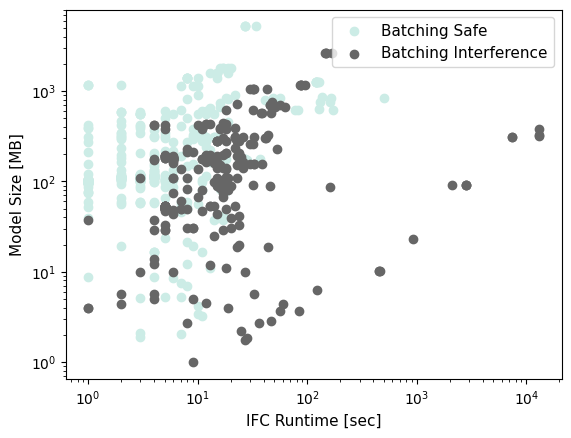

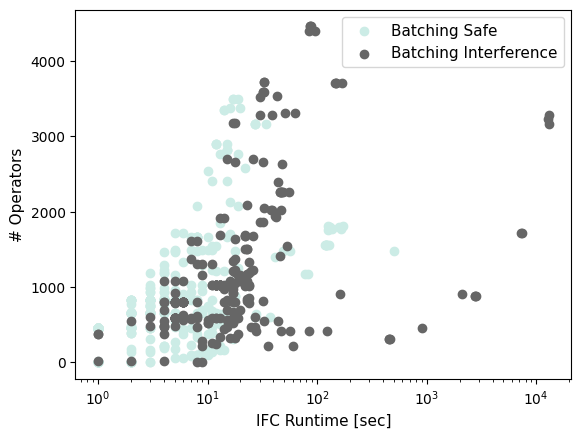

In [6]:
import matplotlib.pyplot as plt


def get_runtime_data(reports):
        data = []
        for doc_id, r in reports:
                r: Report = r
                st = r.stages.interference_check
                if st is not None and st.status in ["noninterference", "interference"]:
                        runtime_sec = st.runtime_sec.get("run")
                        metadata = r.stages.selection.metadata
                        size_bytes = 0
                        for f in metadata["files"]:
                                size_bytes += f["bytes"]
                        n_ops = 0
                        for domain, ops in r.stages.load.operator_histogram.items():
                                for op, count in ops.items():
                                        n_ops += count
                        data.append({"runtime_sec": runtime_sec, "n_ops": n_ops, "model_size_mb": size_bytes / 1e+6, "status": st.status})
        return data

data = get_runtime_data(reports)


x_green = [d["runtime_sec"] for d in data if d["status"] == "noninterference"]
y_green = [d["model_size_mb"] for d in data if d["status"] == "noninterference"]
x_orange = [d["runtime_sec"] for d in data if d["status"] == "interference"]
y_orange = [d["model_size_mb"] for d in data if d["status"] == "interference"]


fontsize = 11
fontsize_axis = 11

plt.xscale('log')
plt.yscale('log')
plt.scatter(x_green, y_green, color='#ccece6', label='Batching Safe')
plt.scatter(x_orange, y_orange, color='#666666', label='Batching Interference')
plt.xlabel('IFC Runtime [sec]', fontsize=fontsize_axis)
plt.ylabel('Model Size [MB]', fontsize=fontsize_axis)
plt.legend(fontsize=fontsize)
plt.savefig("./results/modelsize-runtime.pdf", format="pdf", bbox_inches="tight")
plt.show()


x_green = [d["runtime_sec"] for d in data if d["status"] == "noninterference"]
y_green = [d["n_ops"] for d in data if d["status"] == "noninterference"]
x_orange = [d["runtime_sec"] for d in data if d["status"] == "interference"]
y_orange = [d["n_ops"] for d in data if d["status"] == "interference"]

plt.xscale('log')
#plt.yscale('log')
plt.scatter(x_green, y_green, color='#ccece6', label='Batching Safe')
plt.scatter(x_orange, y_orange, color='#666666', label='Batching Interference')
plt.xlabel('IFC Runtime [sec]', fontsize=fontsize_axis)
plt.ylabel('# Operators', fontsize=fontsize_axis)
plt.legend(fontsize=fontsize)
plt.savefig("./results/nops-runtime.pdf", format="pdf", bbox_inches="tight")
plt.show()

### Analysis

In [7]:
from batching_security_checker.report import stages
from batching_security_checker.report.stages import Stats, StageStat

def compute_stats(reports) -> stages.Stats:
    stats = stages.Stats()

    # COMPUTE STATS
    for doc_id, r in reports:
        r: Report = r

        #if "whisper-" not in r.model_id:
        #    continue

        for stage, stat in zip(r.stages.get_stages(), stats.get_stages(), strict=True):
            if stage is not None:
                stat.update(stage.status)
    return stats


def sankey_matic(stats):

    links = []

    failed = "Failed to Process"

    success_colors = ["#1b9e77", "#3cbf9b", "#66c2a5", "#8fdac3", "#a6e4d1", "#ccece6"]
    failed_colors = ["#d95f02", "#f28e2b", "#fbbf74", "#cccccc", "#999999", "#666666"]

    is_success = True
    is_failed = False




    cfg = {
        ("Download Stage", "success"): ("Downloaded", is_success),
        ("Load Stage", "failed") : (failed, is_failed),
        ("Load Stage", "success") : ("Loaded", is_success),
        ("Shape Inference Stage", "failed") : (failed, is_failed),
        ("Shape Inference Stage", "dynamic") : ("Dynamic Shape", is_failed),
        ("Shape Inference Stage", "fixed") : ("Fixed", is_success),
        ("Batch Dim Stage", "nobatch") : ("Unbatched", is_failed),
        ("Batch Dim Stage", "unknown") : ("Batching Unknown", is_failed),
        ("Batch Dim Stage", "batch") : ("Batched", is_success),
        ("Operator Stage", "missing") : ("Missing Ops", is_failed),
        ("Operator Stage", "available") : ("Support All Ops", is_success),
        ("Interference Check Stage", "failed") : (failed, is_failed),
        ("Interference Check Stage", "interference") : ("Batching Interference", is_failed),
        ("Interference Check Stage", "noninterference"): ("Batching Safe", is_success),
    }

    stage_names = {}
    colors = {}

    i_success = 0
    i_failed = 0
    for k, (name, is_success) in cfg.items():
        stage_names[k] = name
        if is_success and name not in colors:
            colors[name] = success_colors[i_success]
            i_success += 1
        elif (not is_success) and name not in colors:
            #print(f"{name=} {i_failed=}")
            colors[name] = failed_colors[i_failed]
            i_failed += 1
    rich.print(colors)

    def _label(name: str, status: str = None) -> str:
        if status is not None:
            return stage_names.get((name, status), f"{name} - {status}")
        else:
            return stage_names.get(name, name)

    src_name = "onnx-community"
    sts = stats.get_stages()
    for i, stage in enumerate(sts[1:]):
        stage: StageStat = stage
        for s, count in stage.status.items():
            if s != stage.success_status:
                # n fail status
                lbl = _label(stage.stage_name, s)
                color = colors.get(lbl)
                links.append((src_name, lbl, count, color))

        # one success status
        count = stage.status.get(stage.success_status, 0)
        success_name = _label(stage.stage_name, stage.success_status)
        color = colors.get(success_name)
        links.append((src_name, success_name, count, color))
        src_name = success_name

    print("// FORMAT FOR https://sankeymatic.com/build/ :\n")

    for src, dst, count, color in links:
        print(f"{src} [{count}] {dst}")

    print()

    for _, dst, _, color in links:
        print(f":{dst} {color}")

    settings = """// === Settings ===
size w 1200
  h 1200
margin l 0
  r 0
  t 20
  b 20
bg color #ffffff
  transparent N
node w 19
  h 29.5
  spacing 31.5
  border 0
  theme b
  color #000000
  opacity 1
flow curvature 0.38
  inheritfrom target
  color #999999
  opacity 1
layout order exact
  justifyorigins Y
  justifyends Y
  reversegraph N
  attachincompletesto nearest
labels color #000000
  hide N
  highlight 0.75
  fontface sans-serif
  linespacing 0.2
  relativesize 110
  magnify 100
labelname appears Y
  size 16
  weight 400
labelvalue appears Y
  fullprecision Y
  position below
  weight 400
labelposition autoalign 0
  scheme auto
  first before
  breakpoint 8
value format ',.'
  prefix ''
  suffix ''
themeoffset a 1
  b 0
  c 7
  d 0
meta mentionsankeymatic N
  listimbalances Y
    """

    print()
    print(settings)





stats = compute_stats(reports)
sankey_matic(stats)


{
    'Downloaded': '#1b9e77',
    'Failed to Process': '#d95f02',
    'Loaded': '#3cbf9b',
    'Dynamic Shape': '#f28e2b',
    'Fixed': '#66c2a5',
    'Unbatched': '#fbbf74',
    'Batching Unknown': '#cccccc',
    'Batched': '#8fdac3',
    'Missing Ops': '#999999',
    'Support All Ops': '#a6e4d1',
    'Batching Interference': '#666666',
    'Batching Safe': '#ccece6'
}

// FORMAT FOR https://sankeymatic.com/build/ :

onnx-community [1680] Downloaded
Downloaded [42] Failed to Process
Downloaded [1638] Loaded
Loaded [436] Failed to Process
Loaded [355] Dynamic Shape
Loaded [847] Fixed
Fixed [6] Unbatched
Fixed [36] Batching Unknown
Fixed [809] Batched
Batched [146] Missing Ops
Batched [663] Support All Ops
Support All Ops [269] Batching Interference
Support All Ops [33] Failed to Process
Support All Ops [361] Batching Safe

:Downloaded #1b9e77
:Failed to Process #d95f02
:Loaded #3cbf9b
:Failed to Process #d95f02
:Dynamic Shape #f28e2b
:Fixed #66c2a5
:Unbatched #fbbf74
:Batching Unknown #cccccc
:Batched #8fdac3
:Missing Ops #999999
:Support All Ops #a6e4d1
:Batching Interference #666666
:Failed to Process #d95f02
:Batching Safe #ccece6

// === Settings ===
size w 1200
  h 1200
margin l 0
  r 0
  t 20
  b 20
bg color #ffffff
  transparent N
node w 19
  h 29.5
  spacing 31.5
  border 0
  theme b
  color #000000
  opacity 1
flow curvature 0.38
  inheritfrom